# code for the ensemble ssw timing periods computing skill and regression 
It will create the quantile means dataset first and then run the reggresion and correlation at once treating it as a numpy array which will be much faster similar to the sliding window method


In [4]:
import xarray as xr 
import xskillscore as xs
import numpy as np 
import pandas as pd
from importlib import reload 
import matplotlib.pyplot as plt
import os
# import imageio.v2 as imageio
import plotting as pl 
import ensemble_ssw_timing_analysis as sswa
import sliding_window_tele_analysis as ta 

## gather the data

In [5]:
seas5_u10_u100 = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/SEAS5_processed/SEAS5_zonal_mean_zonal_wind_10_100hpa_1981_2025.nc", engine='netcdf4',decode_timedelta=False)
era5_clusters = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/ERA5_6_clusters_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)
seas5_clusters = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/SEAS5_6_clusters_1981_2025_assigned_from_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)
era5_eof = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/ERA5_EOF_z500_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)
seas5_eof = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/SEAS5_EOF_z500_1981_2025_from_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)
era5_nino34_daily_index = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_processed/ERA5_NINO34_daily_NDJFM_clim_NDJ_1940_2025.nc", engine='netcdf4', decode_timedelta=False)
seas5_nino34_daily_index = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/SEAS5_processed/SEAS5_NINO34_daily_NDJFM_clim_NDJ_1981_2025.nc", engine='netcdf4', decode_timedelta=False)
era5_u10_u100 = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_processed/ERA5_ZMZW_1940_2025.nc", engine='netcdf4',decode_timedelta=False)

## align era5 data 

In [6]:
valid_time = seas5_clusters.valid_time
era5_proj_aligned = era5_clusters['Projections'].sel(time=valid_time)

### plot the clusters to check the order

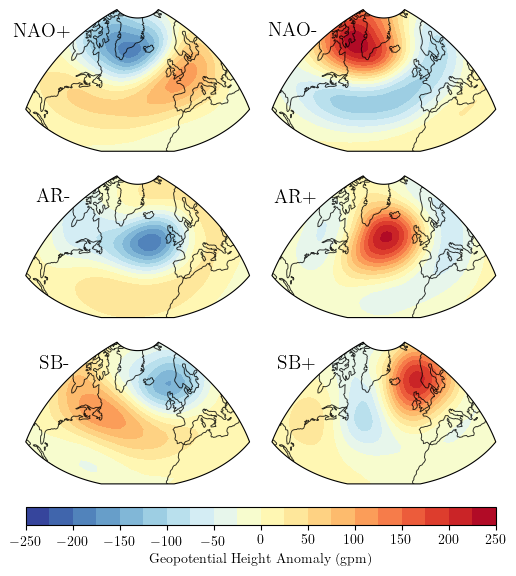

In [7]:
reload(pl)
cluster_order = [2,0,3,5,1,4]
cluster_names = ['NAO+','NAO-','AR-','AR+','SB-','SB+']
title=''

levels = np.linspace(-250, 250, 21)

fig = pl.plot_cluster_centroids(era5_clusters, cluster_names, cluster_order,levels=levels, title=None)


### convert the nino 3.4 daily data to NDJ mean but with broadcasted to shape daily for analysis

In [8]:
era5_enso_index=era5_nino34_daily_index.sst
seas5_enso_index=seas5_nino34_daily_index.sst

seas5_enso_index_ndj_mean = seas5_enso_index.sel(step=slice(0,91*24)).mean(dim='step')
seas5_enso_index_ndj_mean_daily = seas5_enso_index_ndj_mean.sel(time=seas5_enso_index.time)
seas5_enso_index_ndj_mean_daily = seas5_enso_index_ndj_mean_daily.expand_dims(step = seas5_enso_index.step).transpose("time","number","step")
seas5_enso_index_ndj_mean_daily

era5 = era5_enso_index.assign_coords(
    winter_year=xr.where(
        era5_enso_index.time.dt.month <= 3,
        era5_enso_index.time.dt.year - 1,
        era5_enso_index.time.dt.year
    )
)

ndj_mean = (
    era5
    .where(era5.time.dt.month.isin([11, 12, 1]), drop=True)
    .groupby("winter_year")
    .mean("time")
)

ndjfm_mask = era5_enso_index.time.dt.month.isin([11, 12, 1, 2, 3])

winter_year = era5.winter_year

era5_enso_index_ndj_daily = ndj_mean.sel(
    winter_year=winter_year
).where(ndjfm_mask)
era5_enso_index_ndj_daily

<xarray.DataArray 'sst' (time: 13068)> Size: 52kB
array([ 0.7721932 ,  0.7721932 ,  0.7721932 , ..., -0.45613298,
       -0.45613298, -0.45613298], shape=(13068,), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 105kB 1940-01-01 ... 2026-03-01
    winter_year  (time) int64 105kB 1939 1939 1939 1939 ... 2025 2025 2025 2025
    valid_time   (time) datetime64[ns] 105kB 1940-01-01 ... 2026-03-01
Attributes: (12/30)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      105
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_name:                                Sea surface temperature
    GRIB_shortName:                           sst
    GRIB_units:                               K
    long_name:                                Sea surface temperature
    units:                                    K
    standard_name:                            unknown

## get the SSW timings from the ensemble

In [9]:
reload(sswa)
valid_time = seas5_u10_u100.where(seas5_u10_u100.valid_time.dt.month.isin([11,12,1,2,3,4]), drop=True).valid_time
seas5_u10 = seas5_u10_u100.u.sel(isobaricInhPa=10).where(valid_time, drop=True)

onset_steps = sswa.get_ssw_boundaries(seas5_u10)

In [10]:
mask = onset_steps.isnull()


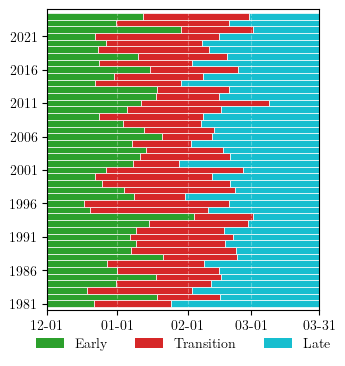

In [11]:
lag = 0 
fig = sswa.ssw_timing_figure(onset_steps+lag*24, seas5_u10.step, seas5_u10.time.dt.year.values, method='dynamic', lq=0.25,uq=0.75)

In [12]:
def compute_ssw_boundaries_grid(first_ssw, lower_qs, upper_qs, method='dynamic'):
    q_all = np.unique(np.concatenate([lower_qs, upper_qs]))
    if method == 'clim':
        q_values = first_ssw.quantile(q_all, dim=["number","time"])
    else:
        q_values = first_ssw.quantile(q_all, dim="number")
    # FIX 1: Rename the dimensions so xarray broadcasts them into a 2D grid
    early = q_values.sel(quantile=lower_qs).rename({"quantile": "lower_q"})
    late = q_values.sel(quantile=upper_qs).rename({"quantile": "upper_q"})

    return xr.Dataset({
        "early": early,
        "late": late
    })

lqs, uqs = np.linspace(0,0.5,11), np.linspace(0.5,1.0,11)
# lqs, uqs = np.linspace(0,0.5,21), np.linspace(0.5,1.0,21)

boundaries = compute_ssw_boundaries_grid(onset_steps, lqs, uqs, method='dynamic')

In [13]:
def build_period_masks(boundaries, step, start=720, end=3600, lag=0):
    early = boundaries["early"]   # (time, lower_q)
    late = boundaries["late"]     # (time, upper_q)
    # print(early.sel(lower_q=0.5))
    if lag !=0: 
        print(lag)
        early+=lag*24
        late+=lag*24
    # print(early.sel(lower_q=0.5))

    early, late = xr.broadcast(early, late)

    step = xr.DataArray(step, dims=["step"])

    masks = xr.Dataset({
        "Early": (step >= start) & (step <= early),
        "Transition": (step > early) & (step < late),
        "Late": (step >= late) & (step <= end),
    })

    masks["Early+Transition"] = masks["Early"] | masks["Transition"]
    masks["Transition+Late"] = masks["Transition"] | masks["Late"]
    masks["Early+Late"] = masks["Early"] | masks["Late"]

    return masks

masks = build_period_masks(boundaries, seas5_u10.step, start=720, end=3600, lag=0)

In [14]:
def compute_period_features(data, masks, min_days=21):
    out = []

    for period in masks:
        mask = masks[period]
        period_length = mask.sum("step")
        is_valid_length = period_length >= min_days

        period_ds = {}

        if isinstance(data, xr.DataArray):
            # da.where(mask) turns masked-out days into NaN
            # mean("step") takes the average of the period
            # where(is_valid_length) turns the year to NaN if the period was shorter than 21 days
            da_masked = data.where(mask).mean("step").where(is_valid_length)
            period_ds[data.name] = da_masked
        
        else:
            for name, da in data.items():
                da_masked = da.where(mask).mean("step").where(is_valid_length)
                period_ds[name] = da_masked

        ds = xr.Dataset(period_ds).expand_dims(period=[period])
        out.append(ds)

    return xr.concat(out, dim="period")


In [15]:
min_days = 11

seas5_proj = compute_period_features(seas5_clusters['projections'], masks, min_days=min_days)
era5_proj = compute_period_features(era5_proj_aligned, masks, min_days=min_days)

Early Max 2.56
Transition Max 2.62
Late Max 0.59
Early+Transition Max 1.8
Transition+Late Max 0.98
----------------------------------------
Early Mean 2.15
Transition Mean 1.36
Late Mean 0.37
Early+Transition Mean 1.47
Transition+Late Mean 0.92


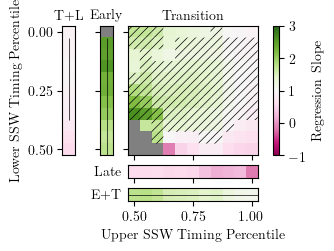

In [17]:
reload(pl)
s5, e5 = xr.align(seas5_proj['projections'].sel(cluster=cluster_order[1]).mean(dim=['number']), era5_proj['Projections'].sel(cluster=cluster_order[1]))

valid_years_count = (s5.notnull() & e5.notnull()).sum(dim="time")

beta = xs.linslope(s5, e5, dim="time", skipna=True)
p = xs.pearson_r_p_value(s5, e5, dim="time", skipna=True)

beta = beta.where(valid_years_count >= 21)
p = p.where(valid_years_count >= 21)

fig = pl.plot_ensemble_ssw_timing_skill(beta, p, lqs, uqs, metric='slope', pathway=None)
# fig.savefig(f'C:/Users/rc831063/OneDrive - University of Reading/PhD/Figures/Ensemble SSW Timing Segmentation/paper ready skill/NAO-_beta_SEAS5_1981_2025_and_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly_min_11d_21y_15lag.pdf')
plt.show()

Early Max 0.46
Transition Max 0.54
Late Max 0.21
Early+Transition Max 0.34
Transition+Late Max 0.33
----------------------------------------
Early Mean 0.37
Transition Mean 0.36
Late Mean 0.13
Early+Transition Mean 0.32
Transition+Late Mean 0.32


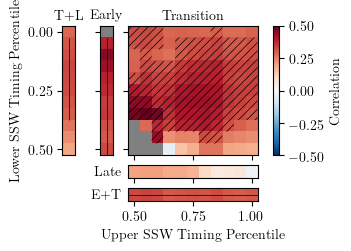

In [19]:

onset_steps = sswa.get_ssw_boundaries(seas5_u10)
seas5_proj_wo_ssw_members = seas5_proj['projections'].where(onset_steps.isnull()) # for testing skill w/o ssw members

s5, e5 = xr.align(seas5_proj['projections'].sel(cluster=cluster_order[1]).mean(dim=['number']), era5_proj['Projections'].sel(cluster=cluster_order[1]))

corr = xs.pearson_r(s5, e5, dim="time", skipna=True)
p = xs.pearson_r_p_value(s5, e5, dim="time", skipna=True)

corr = corr.where(valid_years_count >= 21)
p = p.where(valid_years_count >= 21)

fig = pl.plot_ensemble_ssw_timing_skill(corr, p, lqs, uqs, metric='correlation', pathway=None)
# fig.savefig(f'C:/Users/rc831063/OneDrive - University of Reading/PhD/Figures/Ensemble SSW Timing Segmentation/paper ready skill/NAO-_corr_SEAS5_1981_2025_and_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly_min_11d_21y_15lag.pdf')
plt.show()